Using device: cuda
  GPU      : NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM     : 4.0 GB
  PyTorch  : 2.7.1+cu118
Source model (Inception-Res) | trainable params: 174,869
✓ Pretrained weights loaded from: ./data/inception_res_linnaeus5.pth
\nFeature-extractor params : 173,584
Original FC head params  : 1,285
Detected classes (5): ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total images: 3670
   daisy       :  633
   dandelion   :  898
   roses       :  641
   sunflowers  :  699
   tulips      :  799
\nSplit  →  Train: 2569 | Val: 367 | Test: 734


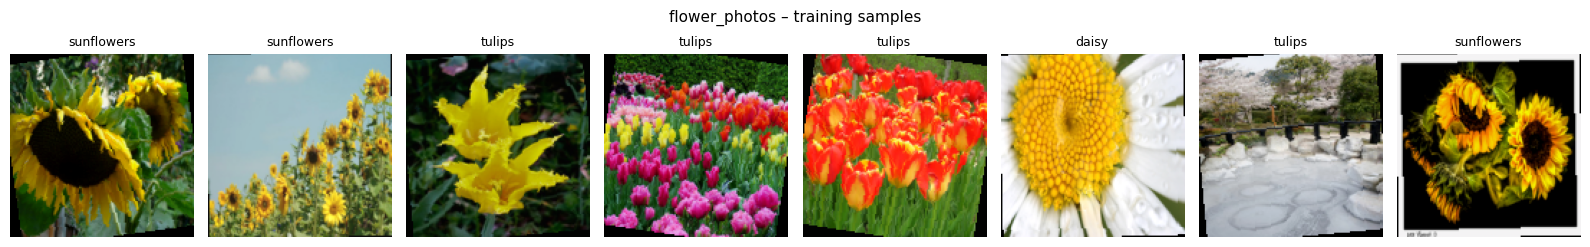

Transfer model ready  |  Total params: 207,381  |  Trainable (before freeze): 207,381
TransferModel(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): InceptionResBlock(
    (incep): InceptionBlock(
      (b1): Sequential(
        (0): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (b2): Sequential(
        (0): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, tra

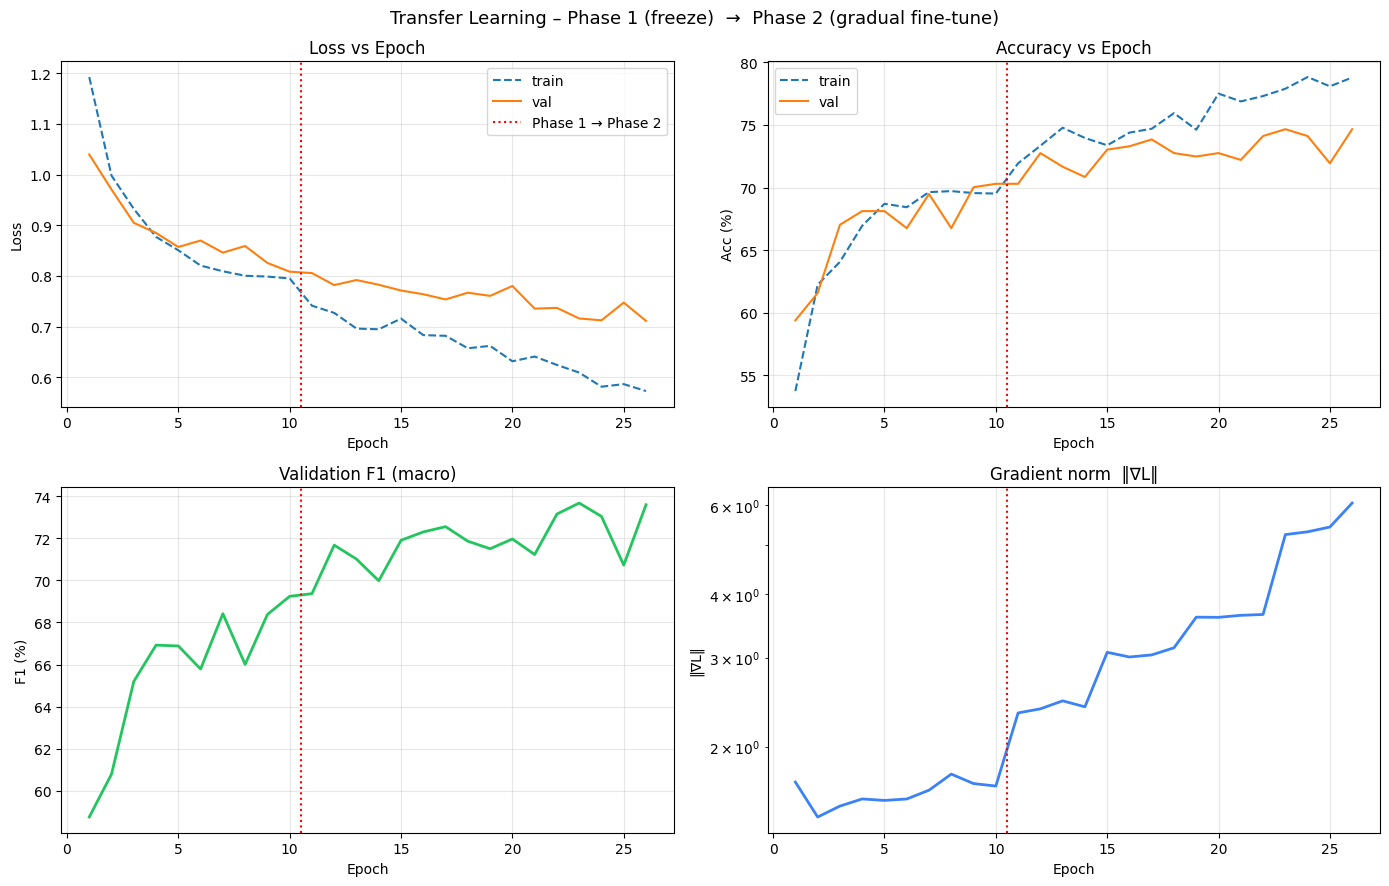

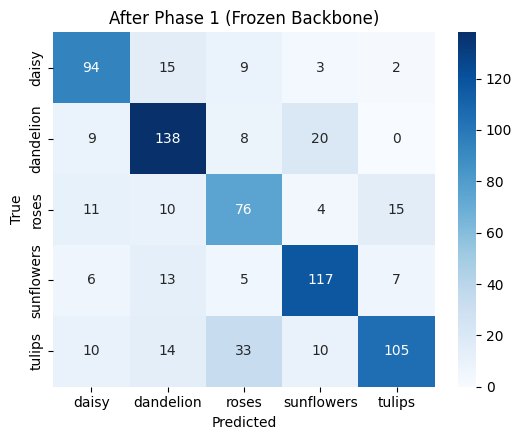

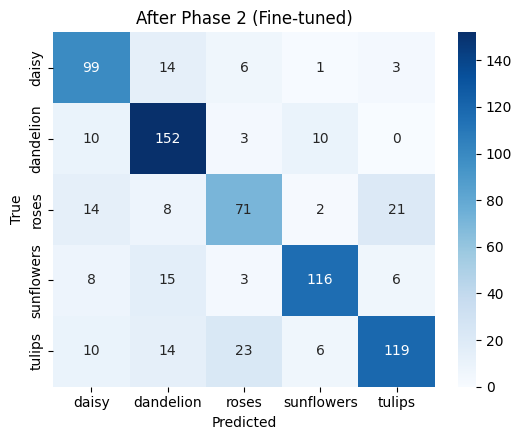

\n=================  FINAL TRANSFER-LEARNING METRICS  =================
              Stage  Test Acc  Test F1  Test Prec  Test Rec  Test Loss
   Phase 1 — Freeze    72.207   71.743     72.065    72.180      0.771
Phase 2 — Fine-tune    75.886   75.102     75.572    75.223      0.691


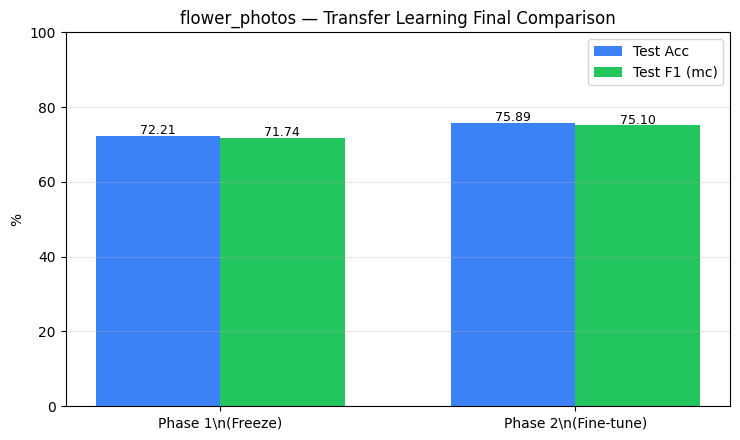

done


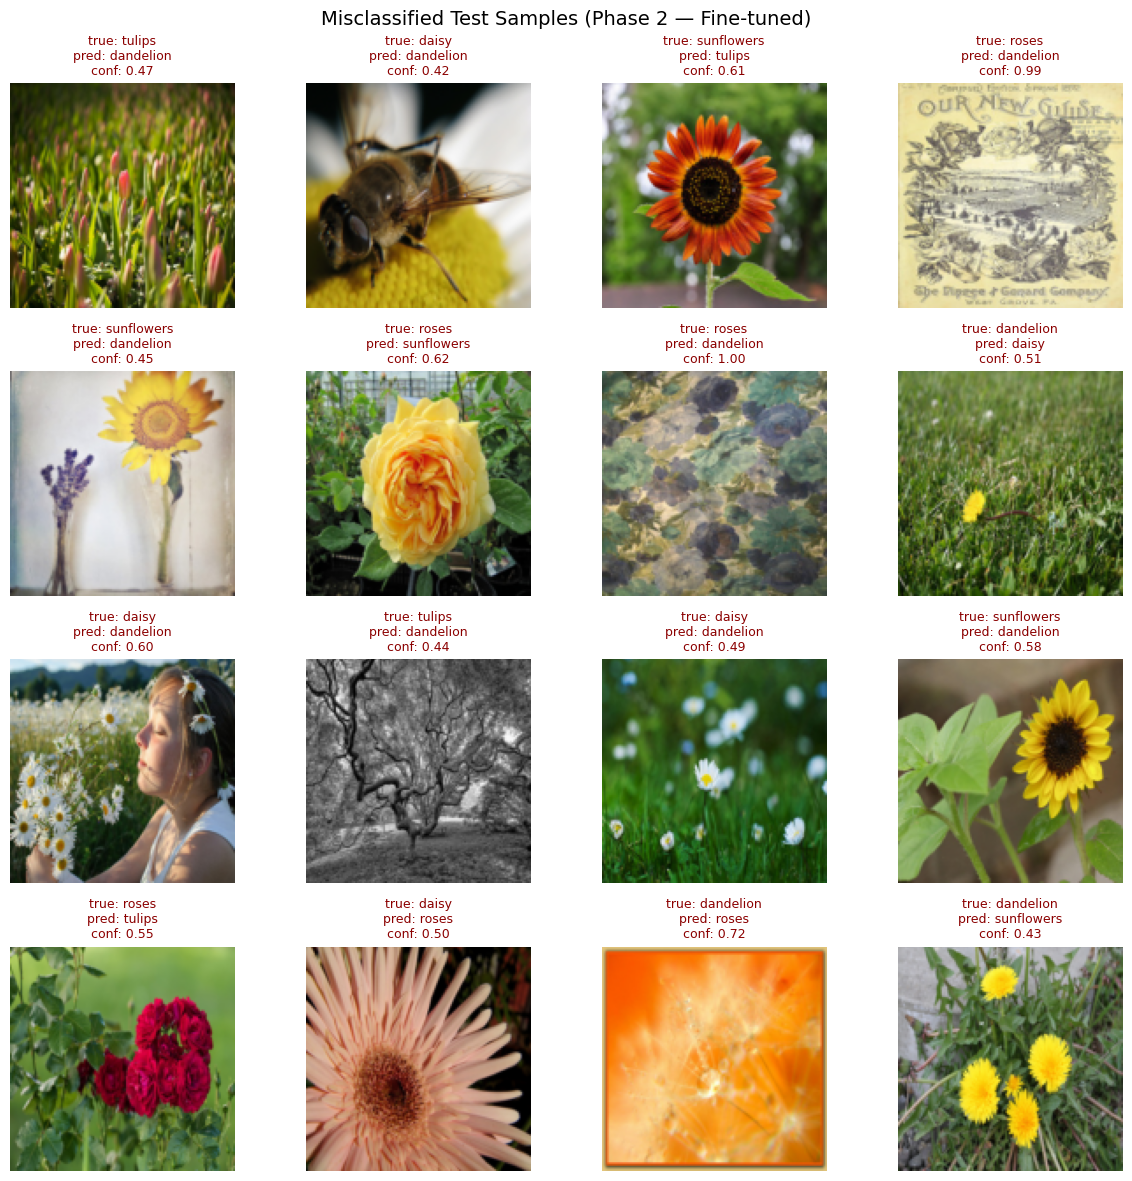

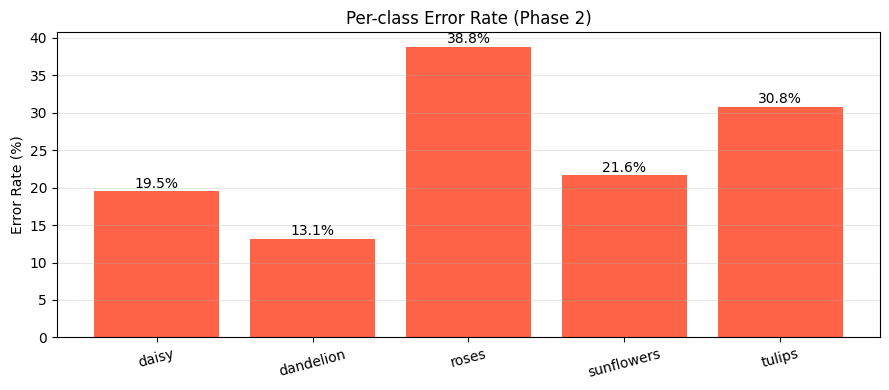


Top most-confused class pairs (true → predicted):
         tulips  →  roses         : 23 samples
          roses  →  tulips        : 21 samples
     sunflowers  →  dandelion     : 15 samples
          daisy  →  dandelion     : 14 samples
          roses  →  daisy         : 14 samples
         tulips  →  dandelion     : 14 samples
      dandelion  →  daisy         : 10 samples


In [1]:
#----------------------------------------------------Kasra Attar Kashani ----------------------------
#---------------------------------------------------Deep Learning - HW3 -------------------------------------
#--------------------------------------------------- TASK 4 -------------------------------------------------
#-------------Transfer Learning flower_photos ---------------------------------------------------------------

import os, time, copy, math, random, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset

import torchvision
from torchvision import datasets, transforms
from PIL import Image

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)
import seaborn as sns

# ---- Reproducibility ----
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark    = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU      : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print(f'  PyTorch  : {torch.__version__}')

# ===== Inception Block (دقیقاً مطابق Task 3) =====
class InceptionBlock(nn.Module):
    def __init__(self, in_c, c1, c3_reduce, c3, c5_reduce, c5, cp):
        super().__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(in_c, c1, 1, bias=False),
            nn.BatchNorm2d(c1), nn.ReLU(inplace=True))
        self.b2 = nn.Sequential(
            nn.Conv2d(in_c, c3_reduce, 1, bias=False),
            nn.BatchNorm2d(c3_reduce), nn.ReLU(inplace=True),
            nn.Conv2d(c3_reduce, c3, 3, padding=1, bias=False),
            nn.BatchNorm2d(c3), nn.ReLU(inplace=True))
        self.b3 = nn.Sequential(
            nn.Conv2d(in_c, c5_reduce, 1, bias=False),
            nn.BatchNorm2d(c5_reduce), nn.ReLU(inplace=True),
            nn.Conv2d(c5_reduce, c5, 5, padding=2, bias=False),
            nn.BatchNorm2d(c5), nn.ReLU(inplace=True))
        self.b4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_c, cp, 1, bias=False),
            nn.BatchNorm2d(cp), nn.ReLU(inplace=True))
        self.out_channels = c1 + c3 + c5 + cp
    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)


# ===== Inception-Residual Block =====
class InceptionResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        c1   = out_c // 4
        c3   = out_c // 4
        c5   = out_c // 4
        cp   = out_c - 3*(out_c // 4)
        c3r  = max(out_c // 8, 4)
        c5r  = max(out_c // 8, 4)
        self.incep = InceptionBlock(in_c, c1, c3r, c3, c5r, c5, cp)
        self.down  = nn.MaxPool2d(stride) if stride > 1 else nn.Identity()
        self.bn    = nn.BatchNorm2d(out_c)
        if stride != 1 or in_c != out_c:
            self.short = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c))
        else:
            self.short = nn.Identity()
    def forward(self, x):
        y = self.incep(x); y = self.down(y); y = self.bn(y)
        s = self.short(x)
        return F.relu(y + s, inplace=True)


# ===== Full Inception-Residual CNN  (source-task model) =====
class InceptionResCNN(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()
        self.stem  = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.layer1 = InceptionResBlock(32,  32,  stride=2)   # 128→64
        self.layer2 = InceptionResBlock(32,  64,  stride=2)   #  64→32
        self.layer3 = InceptionResBlock(64,  128, stride=2)   #  32→16
        self.layer4 = InceptionResBlock(128, 256, stride=2)   #  16→ 8
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).flatten(1)
        return self.fc(self.dropout(x))


# نمونه‌سازی مدل با ۵ کلاس (مطابق Linnaeus 5)
SOURCE_NUM_CLASSES = 5
source_model = InceptionResCNN(num_classes=SOURCE_NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in source_model.parameters() if p.requires_grad)
print(f'Source model (Inception-Res) | trainable params: {n_params:,}')

# ----- مسیر وزن‌های پیش‌آموزش‌دیده -----
PRETRAINED_PATH = './data/inception_res_linnaeus5.pth'

if os.path.isfile(PRETRAINED_PATH):
    state = torch.load(PRETRAINED_PATH, map_location=device)
    source_model.load_state_dict(state)
    print(f'✓ Pretrained weights loaded from: {PRETRAINED_PATH}')
    pretrained_ok = True
else:
    print(f'⚠  Pretrained file not found at: {PRETRAINED_PATH}')
    print('   The transfer-learning pipeline will still run, but the')
    print('   "source" model carries random weights. To use the real')
    print('   Task-3 model, save it via:')
    print('       torch.save(inception_model.state_dict(),')
    print(f'                  "{PRETRAINED_PATH}")')
    pretrained_ok = False

# تعداد پارامترهای استخراج‌کنندهٔ ویژگی
feat_params = sum(p.numel() for n,p in source_model.named_parameters() if not n.startswith('fc'))
fc_params   = sum(p.numel() for n,p in source_model.named_parameters() if     n.startswith('fc'))
print(f'\\nFeature-extractor params : {feat_params:,}')
print(f'Original FC head params  : {fc_params:,}')


# ----- مسیر دیتاست -----
# مطابق فایل‌سیستم کاربر:
#   C:\\Users\\USER\\Desktop\\DL_HW3\\data\\flower_photos
# پس مسیر نسبی به نوت‌بوک:
FLOWER_ROOT = './data/flower_photos'

# ----- پارامترها -----
IMG_SIZE  = 128                                        # ورودی شبکه (مطابق Task 3)
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
BATCH     = 64

# ----- تبدیلات -----
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ----- ImageFolder -----
full_set = datasets.ImageFolder(FLOWER_ROOT, transform=train_transform)
TGT_CLASSES = full_set.classes
TGT_NUM_CLASSES = len(TGT_CLASSES)
print(f'Detected classes ({TGT_NUM_CLASSES}): {TGT_CLASSES}')
print(f'Total images: {len(full_set)}')

# توزیع کلاس‌ها
from collections import Counter
counts = Counter([lbl for _, lbl in full_set.samples])
for cls, idx in zip(TGT_CLASSES, range(TGT_NUM_CLASSES)):
    print(f'   {cls:<12s}: {counts[idx]:4d}')

# ----- تقسیم 70/10/20 -----
n_total = len(full_set)
n_train = int(0.70 * n_total)
n_val   = int(0.10 * n_total)
n_test  = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset, test_subset = random_split(
    full_set, [n_train, n_val, n_test], generator=generator
)

# wrapper برای اعمال تبدیل eval روی val و test
class _WrapWithTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img_path, lbl = self.subset.dataset.samples[self.subset.indices[i]]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), lbl

val_set  = _WrapWithTransform(val_subset,  eval_transform)
test_set = _WrapWithTransform(test_subset, eval_transform)

print(f'\\nSplit  →  Train: {len(train_subset)} | Val: {len(val_set)} | Test: {len(test_set)}')

train_loader = DataLoader(train_subset, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,      batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_set,     batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

# نمایش چند نمونه از تصاویر آموزش
def imshow_grid(loader, class_names, n=8, title='flower_photos – training samples'):
    images, labels = next(iter(loader))
    images = images[:n]; labels = labels[:n]
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2.5))
    inv_norm = transforms.Normalize(mean=[-m/s for m,s in zip(MEAN, STD)],
                                     std =[1/s for s in STD])
    for ax, img, lbl in zip(axes, images, labels):
        img = inv_norm(img).clamp(0,1).permute(1,2,0).cpu().numpy()
        ax.imshow(img); ax.axis('off'); ax.set_title(class_names[lbl], fontsize=9)
    plt.suptitle(title, fontsize=11)
    plt.tight_layout(); plt.show()

imshow_grid(train_loader, TGT_CLASSES, n=8)

class TransferModel(nn.Module):
    # مدل انتقال یادگیری: backbone از source_model + classifier جدید
    def __init__(self, source: InceptionResCNN, num_classes: int,
                 head_hidden: int = 128, dropout: float = 0.4):
        super().__init__()
        # ---------- استخراج‌کنندهٔ ویژگی (همان Backbone شبکهٔ Inception-Res) ----------
        self.stem   = source.stem
        self.layer1 = source.layer1
        self.layer2 = source.layer2
        self.layer3 = source.layer3
        self.layer4 = source.layer4
        self.gap    = source.gap

        # ---------- دسته‌بند جدید ----------
        # عمداً کمی پیچیده‌تر از یک Linear تنها انتخاب شده تا در پاسخ نهایی
        # دربارهٔ اثر پیچیدگی دسته‌بند بحث کنیم.
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # (B, 256, 1, 1)  →  (B, 256)
            nn.Linear(256, head_hidden),
            nn.BatchNorm1d(head_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, num_classes)
        )

    # ----- مفید برای کنترل freeze/unfreeze در یک تابع متمرکز -----
    def feature_parameters(self):
        for m in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in m.parameters(): yield p

    def classifier_parameters(self):
        return self.classifier.parameters()

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x)
        return self.classifier(x)


tl_model = TransferModel(source_model, num_classes=TGT_NUM_CLASSES,
                         head_hidden=128, dropout=0.4).to(device)

total_p   = sum(p.numel() for p in tl_model.parameters())
trainable = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f'Transfer model ready  |  Total params: {total_p:,}  |  Trainable (before freeze): {trainable:,}')
print(tl_model)


def compute_grad_norm(model):
    total_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_sq += p.grad.detach().norm(2).item() ** 2
    return math.sqrt(total_sq)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    grad_norms = []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        grad_norms.append(compute_grad_norm(model))
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
    return running_loss/total, 100.*correct/total, float(np.mean(grad_norms))

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        out  = model(x)
        loss = criterion(out, y)
        running_loss += loss.item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
        all_preds.append(pred.cpu().numpy()); all_labels.append(y.cpu().numpy())
    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return running_loss/total, 100.*correct/total, \
           100.*f1_score(all_labels, all_preds, average='macro'), all_preds, all_labels

def fit(model, train_loader, val_loader, *, epochs, lr, weight_decay,
        device, name, params_to_optimize=None):
    criterion = nn.CrossEntropyLoss()
    params    = params_to_optimize if params_to_optimize is not None \
                else [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params, lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                    factor=0.5, patience=2)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
               'val_f1':[], 'grad_norm':[], 'lr':[]}
    best_va, best_state = 0.0, None
    t0 = time.time()
    for ep in range(1, epochs+1):
        tl, ta, gn = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, va, vf, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(va)
        cur_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        history['val_f1'].append(vf);     history['grad_norm'].append(gn)
        history['lr'].append(cur_lr)
        if va > best_va:
            best_va, best_state = va, copy.deepcopy(model.state_dict())
        print(f'[{name}] Ep{ep:02d}/{epochs} | '
              f'TL {tl:.3f} TA {ta:5.2f}% | VL {vl:.3f} VA {va:5.2f}% F1 {vf:5.2f}% | '
              f'‖∇‖ {gn:7.3f} | lr {cur_lr:.1e}')
    if best_state is not None:
        model.load_state_dict(best_state)
    history['train_time_sec'] = time.time() - t0
    history['best_val_acc']   = best_va
    return history


# ---- منجمد کردن استخراج‌کنندهٔ ویژگی ----
for p in tl_model.feature_parameters():
    p.requires_grad = False

# اعتبارسنجی
n_frozen   = sum(p.numel() for p in tl_model.feature_parameters())
n_trainable= sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f'❄  Frozen   params : {n_frozen:,}')
print(f'🔥 Trainable params : {n_trainable:,}   (only the new classifier)')

# نکته: لایه‌های BatchNorm را در حالت eval قرار می‌دهیم تا آمار running ثابت بماند
def set_bn_eval(model):
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.eval()

# wrap اطراف train() تا هربار BNها بسته بمانند
_orig_train = tl_model.train
def _train_with_bn_frozen(mode=True):
    _orig_train(mode)
    if mode:
        # BN لایه‌های backbone را در eval نگه‌داریم
        for m in [tl_model.stem, tl_model.layer1, tl_model.layer2,
                  tl_model.layer3, tl_model.layer4]:
            for sub in m.modules():
                if isinstance(sub, (nn.BatchNorm1d, nn.BatchNorm2d)):
                    sub.eval()
    return tl_model
tl_model.train = _train_with_bn_frozen

# ---- آموزش فاز ۱ (فقط دسته‌بند) ----
EPOCHS_PHASE1 = 10
LR_PHASE1     = 1e-3

hist_freeze = fit(tl_model, train_loader, val_loader,
                  epochs=EPOCHS_PHASE1, lr=LR_PHASE1, weight_decay=1e-4,
                  device=device, name='Phase1-Freeze',
                  params_to_optimize=list(tl_model.classifier_parameters()))

# ارزیابی روی تست پس از فاز ۱
criterion = nn.CrossEntropyLoss()
tl_p1, ta_p1, tf_p1, preds_p1, lbls_p1 = evaluate(tl_model, test_loader, criterion, device)
print(f'\\n[After Phase 1]  Test Loss = {tl_p1:.4f}  |  Test Acc = {ta_p1:.2f}%  |  Test F1 = {tf_p1:.2f}%')


def unfreeze(module):
    for p in module.parameters():
        p.requires_grad = True

# جدول مراحل آزاد سازی تدریجی
unfreeze_schedule = [
    ('Stage-A  unfreeze layer4',           [tl_model.layer4]),
    ('Stage-B  unfreeze layer4+layer3',    [tl_model.layer4, tl_model.layer3]),
    ('Stage-C  unfreeze layer4..layer2',   [tl_model.layer4, tl_model.layer3, tl_model.layer2]),
    ('Stage-D  unfreeze ALL (incl. stem)', [tl_model.stem, tl_model.layer1,
                                            tl_model.layer2, tl_model.layer3, tl_model.layer4]),
]

EPOCHS_PER_STAGE = 4
LR_PHASE2        = 1e-4   # یک‌دهم فاز ۱

# تابع کمکی برای ادغام تاریخچه‌ها
def merge_histories(h_list):
    keys = ['train_loss','val_loss','train_acc','val_acc','val_f1','grad_norm','lr']
    merged = {k: [] for k in keys}
    for h in h_list:
        for k in keys: merged[k].extend(h[k])
    return merged

stage_histories = []
for stage_name, modules_to_open in unfreeze_schedule:
    # ۱) ابتدا backbone را کاملاً منجمد می‌کنیم (تا فقط آن‌چه می‌خواهیم آزاد شود)
    for p in tl_model.feature_parameters():
        p.requires_grad = False
    # ۲) ماژول‌های مرحله جاری را آزاد می‌کنیم
    for m in modules_to_open:
        unfreeze(m)
    # ۳) دسته‌بند هم همیشه آزاد می‌ماند
    for p in tl_model.classifier_parameters():
        p.requires_grad = True

    n_train = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
    print(f'\\n=========  {stage_name}  =========')
    print(f'   Trainable params now: {n_train:,}')

    h = fit(tl_model, train_loader, val_loader,
            epochs=EPOCHS_PER_STAGE, lr=LR_PHASE2, weight_decay=1e-4,
            device=device, name=stage_name.split()[0],
            params_to_optimize=[p for p in tl_model.parameters() if p.requires_grad])
    stage_histories.append(h)

hist_finetune = merge_histories(stage_histories)

# ارزیابی نهایی روی Test
tl_p2, ta_p2, tf_p2, preds_p2, lbls_p2 = evaluate(tl_model, test_loader, criterion, device)
print(f'\\n[After Fine-tuning]  Test Loss = {tl_p2:.4f}  |  Test Acc = {ta_p2:.2f}%  |  Test F1 = {tf_p2:.2f}%')
print('\\nClassification report:')
print(classification_report(lbls_p2, preds_p2, target_names=TGT_CLASSES, digits=4))


# ----- ادغام تاریخچهٔ کل (فاز ۱ + فاز ۲) -----
hist_total = {
    'train_loss': hist_freeze['train_loss'] + hist_finetune['train_loss'],
    'val_loss'  : hist_freeze['val_loss']   + hist_finetune['val_loss'],
    'train_acc' : hist_freeze['train_acc']  + hist_finetune['train_acc'],
    'val_acc'   : hist_freeze['val_acc']    + hist_finetune['val_acc'],
    'val_f1'    : hist_freeze['val_f1']     + hist_finetune['val_f1'],
    'grad_norm' : hist_freeze['grad_norm']  + hist_finetune['grad_norm'],
    'lr'        : hist_freeze['lr']         + hist_finetune['lr'],
}

n_p1 = len(hist_freeze['train_loss'])
n_total = len(hist_total['train_loss'])
epochs_x = np.arange(1, n_total+1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Loss
ax = axes[0,0]
ax.plot(epochs_x, hist_total['train_loss'], '--', label='train')
ax.plot(epochs_x, hist_total['val_loss'],         label='val')
ax.axvline(n_p1+0.5, color='red', ls=':', label='Phase 1 → Phase 2')
ax.set_title('Loss vs Epoch'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=.3)

# Accuracy
ax = axes[0,1]
ax.plot(epochs_x, hist_total['train_acc'], '--', label='train')
ax.plot(epochs_x, hist_total['val_acc'],         label='val')
ax.axvline(n_p1+0.5, color='red', ls=':')
ax.set_title('Accuracy vs Epoch'); ax.set_xlabel('Epoch'); ax.set_ylabel('Acc (%)')
ax.legend(); ax.grid(alpha=.3)

# F1
ax = axes[1,0]
ax.plot(epochs_x, hist_total['val_f1'], lw=2, color='#22c55e')
ax.axvline(n_p1+0.5, color='red', ls=':')
ax.set_title('Validation F1 (macro)'); ax.set_xlabel('Epoch'); ax.set_ylabel('F1 (%)')
ax.grid(alpha=.3)

# Grad norm  (انتظار: در فاز ۲ افزایش می‌یابد چون لایه‌های بیشتری گرادیان دارند)
ax = axes[1,1]
ax.plot(epochs_x, hist_total['grad_norm'], lw=2, color='#3b82f6')
ax.axvline(n_p1+0.5, color='red', ls=':')
ax.set_title('Gradient norm  ‖∇L‖'); ax.set_xlabel('Epoch'); ax.set_ylabel('‖∇L‖')
ax.set_yscale('log'); ax.grid(alpha=.3)

plt.suptitle('Transfer Learning – Phase 1 (freeze)  →  Phase 2 (gradual fine-tune)', fontsize=13)
plt.tight_layout(); plt.show()


# ----- ماتریس درهم‌ریختگی پس از فاز ۲ -----
def plot_cm(labels, preds, title, classes):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5.5,4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

plot_cm(lbls_p1, preds_p1, 'After Phase 1 (Frozen Backbone)', TGT_CLASSES)
plot_cm(lbls_p2, preds_p2, 'After Phase 2 (Fine-tuned)',      TGT_CLASSES)

# جدول مقایسه دو فاز
prec_p1 = 100*precision_score(lbls_p1, preds_p1, average='macro')
rec_p1  = 100*recall_score   (lbls_p1, preds_p1, average='macro')
prec_p2 = 100*precision_score(lbls_p2, preds_p2, average='macro')
rec_p2  = 100*recall_score   (lbls_p2, preds_p2, average='macro')

df = pd.DataFrame([
    {'Stage':'Phase 1 — Freeze',     'Test Acc':ta_p1, 'Test F1':tf_p1,
     'Test Prec':prec_p1, 'Test Rec':rec_p1, 'Test Loss':tl_p1},
    {'Stage':'Phase 2 — Fine-tune',  'Test Acc':ta_p2, 'Test F1':tf_p2,
     'Test Prec':prec_p2, 'Test Rec':rec_p2, 'Test Loss':tl_p2},
])
print('\\n=================  FINAL TRANSFER-LEARNING METRICS  =================')
print(df.to_string(index=False, float_format=lambda x: f'{x:7.3f}'))


# نمودار میله‌ای مقایسه نهایی
labels_x = ['Phase 1\\n(Freeze)', 'Phase 2\\n(Fine-tune)']
acc_v = [ta_p1, ta_p2]
f1_v  = [tf_p1, tf_p2]

x = np.arange(len(labels_x)); w = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar(x - w/2, acc_v, w, label='Test Acc',     color='#3b82f6')
b2 = ax.bar(x + w/2, f1_v,  w, label='Test F1 (mc)', color='#22c55e')
ax.set_xticks(x); ax.set_xticklabels(labels_x)
ax.set_ylim(0, 100); ax.set_ylabel('%')
ax.set_title('flower_photos — Transfer Learning Final Comparison')
ax.legend(); ax.grid(alpha=.3, axis='y')
for b in [*b1, *b2]:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f'{b.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print('done')

# ==========================================================
#  Error Analysis  ─  نمایش تصاویر طبقه‌بندی شده اشتباه
#  از پیش‌بینی‌های فاز ۲ (fine-tuned) استفاده می‌شود
# ==========================================================
import torch.nn.functional as F_

def show_misclassified(model, test_loader, class_names, n_show=16):
    model.eval()
    wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []
    inv_norm = transforms.Normalize(mean=[-m/s for m, s in zip(MEAN, STD)],
                                     std =[1/s for s in STD])
    with torch.no_grad():
        for x, y in test_loader:
            x_dev = x.to(device)
            logits = model(x_dev)
            probs  = F_.softmax(logits, dim=1)
            conf, pred = probs.max(1)
            mask = pred.cpu() != y
            if mask.any():
                for i in torch.where(mask)[0]:
                    if len(wrong_imgs) >= n_show:
                        break
                    wrong_imgs.append(x[i])
                    wrong_true.append(int(y[i]))
                    wrong_pred.append(int(pred[i].cpu()))
                    wrong_conf.append(float(conf[i].cpu()))
            if len(wrong_imgs) >= n_show:
                break

    cols = 4; rows = int(np.ceil(len(wrong_imgs)/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    axes = np.array(axes).flatten()
    for ax, img, t, p, c in zip(axes, wrong_imgs, wrong_true, wrong_pred, wrong_conf):
        img_np = inv_norm(img).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
        ax.imshow(img_np); ax.axis('off')
        ax.set_title(f'true: {class_names[t]}\npred: {class_names[p]}\nconf: {c:.2f}',
                     fontsize=9, color='darkred')
    for ax in axes[len(wrong_imgs):]:
        ax.axis('off')
    plt.suptitle('Misclassified Test Samples (Phase 2 — Fine-tuned)', fontsize=14)
    plt.tight_layout(); plt.savefig('task4_error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # هیستوگرام خطا براساس کلاسِ واقعی
    cm = confusion_matrix(lbls_p2, preds_p2)
    per_class_err = cm.sum(axis=1) - cm.diagonal()
    per_class_tot = cm.sum(axis=1)
    err_rate = per_class_err / np.maximum(per_class_tot, 1) * 100

    plt.figure(figsize=(9, 4))
    bars = plt.bar(class_names, err_rate, color='tomato')
    plt.ylabel('Error Rate (%)')
    plt.title('Per-class Error Rate (Phase 2)')
    for b, v in zip(bars, err_rate):
        plt.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%',
                 ha='center', fontsize=10)
    plt.xticks(rotation=15); plt.grid(alpha=.3, axis='y')
    plt.tight_layout(); plt.show()

    # بدترین جفت‌های اشتباه
    cm_copy = cm.copy()
    np.fill_diagonal(cm_copy, 0)
    flat = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if cm_copy[i, j] > 0:
                flat.append((class_names[i], class_names[j], cm_copy[i, j]))
    flat.sort(key=lambda t: -t[2])
    print('\nTop most-confused class pairs (true → predicted):')
    for true_c, pred_c, n in flat[:7]:
        print(f'   {true_c:>12s}  →  {pred_c:<12s}  : {n} samples')

show_misclassified(tl_model, test_loader, TGT_CLASSES, n_show=16)
